# Module 2 — Emotion Classifier
This notebook covers all stages of the emotion classification pipeline:
1. **EDA & Preprocessing** — Load, clean, and explore the dataset
2. **Baseline Model** — TF-IDF + Logistic Regression
3. **DistilBERT Training** — Fine-tune a transformer model
4. **Evaluation** — Test the trained DistilBERT model

---
## 0. Setup

In [2]:
# Install dependencies
# Run once in your terminal: pip install transformers datasets scikit-learn pandas matplotlib seaborn
import subprocess, sys
subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q',
    'transformers', 'datasets', 'scikit-learn', 'pandas', 'matplotlib', 'seaborn', 'accelerate'])


0

In [3]:
from pathlib import Path

# Local paths for VS Code
BASE_DIR   = Path().resolve().parent

DATA_DIR   = BASE_DIR / 'data'
OUTPUT_DIR = BASE_DIR / 'outputs/module2/'
MODEL_DIR  = BASE_DIR / 'models'
BERT_DIR   = MODEL_DIR / 'distilbert'

DATA_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
MODEL_DIR.mkdir(parents=True, exist_ok=True)
BERT_DIR.mkdir(parents=True, exist_ok=True)

print('Data      ->', DATA_DIR)
print('Outputs   ->', OUTPUT_DIR)
print('Models    ->', MODEL_DIR)


Data      -> D:\ITI\NLP\NLP_ptoject_trial\mental_health_chatbot\Mental-Health-RAG-Chatbot\data
Outputs   -> D:\ITI\NLP\NLP_ptoject_trial\mental_health_chatbot\Mental-Health-RAG-Chatbot\outputs\module2
Models    -> D:\ITI\NLP\NLP_ptoject_trial\mental_health_chatbot\Mental-Health-RAG-Chatbot\models


---
## 1. EDA & Preprocessing

In [4]:
import os
import re
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset

c:\Users\alaaa\AppData\Local\Programs\Python\Python310\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [5]:
# Loading dataset
dataset = load_dataset('dair-ai/emotion')
label_names = dataset['train'].features['label'].names
# the 6 classes --> ['sadness', 'joy', 'love', 'anger', 'fear', 'surprise']

# Change dataset to dataframe and add emotion labels and text length
def to_df(split):
    df = pd.DataFrame(dataset[split])
    df.columns = ['text', 'label']
    df['emotion'] = df['label'].map(lambda x: label_names[x])
    df['length']  = df['text'].apply(lambda x: len(x.split()))
    return df

df_train = to_df('train')
df_val   = to_df('validation')
df_test  = to_df('test')

In [6]:
def preprocess(df: pd.DataFrame, split_name: str) -> pd.DataFrame:
    original_len = len(df)

    # Drop duplicates
    df = df.drop_duplicates(subset=['text', 'label'])
    dupes_dropped = original_len - len(df)

    # Drop null/empty texts
    df = df[df['text'].notna()]
    df = df[df['text'].str.strip() != '']

    # Strip HTML artifacts
    df['text'] = df['text'].str.replace(r'<[^>]+>', '', regex=True)
    df['text'] = df['text'].str.replace(r'img\s+src\s+\S+', '', regex=True)
    df['text'] = df['text'].str.replace(r'http\S+', '', regex=True)

    # Normalize whitespace
    df['text'] = df['text'].str.replace(r'\s+', ' ', regex=True).str.strip()

    # Remove rows that became empty after cleaning
    df = df[df['text'].str.strip() != '']

    # Drop extreme-length outliers (too short: <= 2 words, too long: > 300 words)
    df['length'] = df['text'].apply(lambda x: len(x.split()))
    before_len_filter = len(df)
    df = df[(df['length'] >= 3) & (df['length'] <= 300)]
    length_dropped = before_len_filter - len(df)

    print(f'\n=== Preprocessing — {split_name} ===')
    print(f'  Original rows          : {original_len}')
    print(f'  Duplicates dropped     : {dupes_dropped}')
    print(f'  Length outliers dropped: {length_dropped}')
    print(f'  Final rows             : {len(df)}')

    return df.reset_index(drop=True)

df_train = preprocess(df_train, 'train')
df_val   = preprocess(df_val,   'validation')
df_test  = preprocess(df_test,  'test')


=== Preprocessing — train ===
  Original rows          : 16000
  Duplicates dropped     : 1
  Length outliers dropped: 8
  Final rows             : 15991

=== Preprocessing — validation ===
  Original rows          : 2000
  Duplicates dropped     : 0
  Length outliers dropped: 1
  Final rows             : 1999

=== Preprocessing — test ===
  Original rows          : 2000
  Duplicates dropped     : 0
  Length outliers dropped: 0
  Final rows             : 2000


In [7]:
# Save cleaned data to Drive
df_train.to_parquet(DATA_DIR / 'train.parquet', index=False)
df_val.to_parquet(DATA_DIR   / 'val.parquet',   index=False)
df_test.to_parquet(DATA_DIR  / 'test.parquet',  index=False)
print('Saved cleaned data to Drive successfully')

Saved cleaned data to Drive successfully



=== Class Distribution (train) ===
emotion
joy         5359
sadness     4665
anger       2156
fear        1935
love        1304
surprise     572
Name: count, dtype: int64


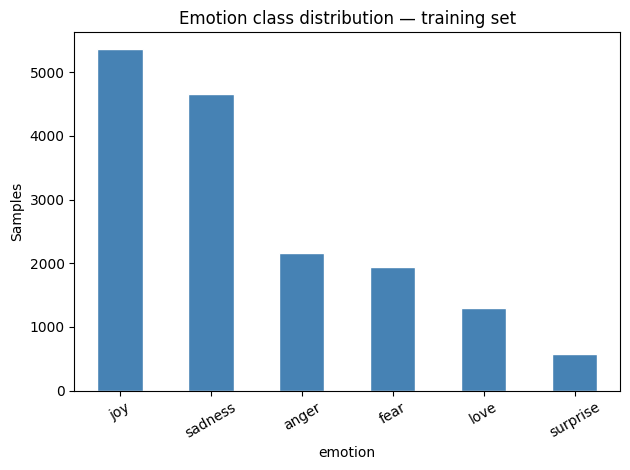

Saved -> class_distribution.png


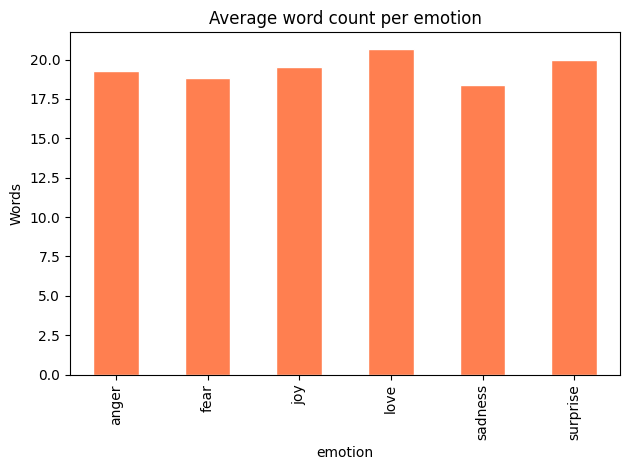

Saved -> length_per_emotion.png

=== Sample texts per emotion ===

--- SADNESS ---
  • im feeling so lousy they tried to cheer me up during school time and during choir practice
  • i feel highly disadvantaged
  • i feel humiliated to introduce you to my colleagues as my wife

--- JOY ---
  • i hate missing practice because i feel like the reps in practice are vital to your performance on sunday
  • i feel very triumphant another personal mini goal accomplished
  • im even starting to feel more sociable

--- LOVE ---
  • i mean fuck i feel like i was way more considerate with customers and concerned about appearance and sanitiation snoozel pm but fine
  • i remember a couple of years ago i was feeling romantic and dreamy and asked him wonder if we ll celebrate our th anniversary
  • im so going to end up feeling slutty and be like ah

--- ANGER ---
  • i feel like im presenting myself in a less hostile manner now when i am dragged to an event or gathering full of stupid fake people
  •

In [8]:
# Class distribution
print('\n=== Class Distribution (train) ===')
print(df_train['emotion'].value_counts())

df_train['emotion'].value_counts().plot(kind='bar', color='steelblue', edgecolor='white')
plt.title('Emotion class distribution — training set')
plt.ylabel('Samples')
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'class_distribution.png')
plt.show()
print('Saved -> class_distribution.png')

# Average text length per emotion
df_train.groupby('emotion')['length'].mean().plot(kind='bar', color='coral', edgecolor='white')
plt.title('Average word count per emotion')
plt.ylabel('Words')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'length_per_emotion.png')
plt.show()
print('Saved -> length_per_emotion.png')

# Sample texts per emotion
print('\n=== Sample texts per emotion ===')
for emotion in label_names:
    print(f'\n--- {emotion.upper()} ---')
    samples = df_train[df_train['emotion'] == emotion]['text'].sample(3, random_state=42)
    for s in samples:
        print(f'  • {s}')

---
## 2. Baseline Model — TF-IDF + Logistic Regression

In [9]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
import pickle

In [10]:
label_names = ['sadness', 'joy', 'love', 'anger', 'fear', 'surprise']
df_train = pd.read_parquet(DATA_DIR / 'train.parquet')
df_val   = pd.read_parquet(DATA_DIR / 'val.parquet')

# TF-IDF + Logistic Regression
vectorizer = TfidfVectorizer(max_features=10000, ngram_range=(1, 2))
X_train = vectorizer.fit_transform(df_train['text'])
X_val   = vectorizer.transform(df_val['text'])

clf = LogisticRegression(max_iter=1000, class_weight='balanced')
clf.fit(X_train, df_train['label'])

preds  = clf.predict(X_val)
report = classification_report(df_val['label'], preds, target_names=label_names)
print('\n=== Baseline Report (TF-IDF + LogReg) ===')
print(report)

with open(OUTPUT_DIR / 'baseline_report.txt', 'w') as f:
    f.write(report)

# Save model
pickle.dump({'vectorizer': vectorizer, 'clf': clf}, open(MODEL_DIR / 'baseline.pkl', 'wb'))
print('Saved -> baseline_report.txt')
print('Saved -> models/baseline.pkl')


=== Baseline Report (TF-IDF + LogReg) ===
              precision    recall  f1-score   support

     sadness       0.92      0.88      0.90       550
         joy       0.93      0.88      0.90       704
        love       0.75      0.94      0.84       178
       anger       0.88      0.88      0.88       275
        fear       0.83      0.82      0.83       211
    surprise       0.72      0.81      0.76        81

    accuracy                           0.88      1999
   macro avg       0.84      0.87      0.85      1999
weighted avg       0.88      0.88      0.88      1999

Saved -> baseline_report.txt
Saved -> models/baseline.pkl


---
## 3. DistilBERT Fine-Tuning

In [11]:
import numpy as np
import torch
from datasets import Dataset, DatasetDict
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding,
    EarlyStoppingCallback,
)
from sklearn.metrics import f1_score

In [13]:
label_names = ['sadness', 'joy', 'love', 'anger', 'fear', 'surprise']
num_labels  = len(label_names)

df_train = pd.read_parquet(DATA_DIR / 'train.parquet')
df_val   = pd.read_parquet(DATA_DIR / 'val.parquet')

hf_dataset = DatasetDict({
    'train':      Dataset.from_pandas(df_train[['text', 'label']]),
    'validation': Dataset.from_pandas(df_val[['text', 'label']]),
})

print(f'Labels: {label_names}')
print(f'Training samples: {len(hf_dataset["train"])}')

# Training configuration
MODEL_NAME = 'distilbert-base-uncased'
MAX_LENGTH = 128
BATCH_SIZE = 32
EPOCHS     = 5
LR         = 2e-5

Labels: ['sadness', 'joy', 'love', 'anger', 'fear', 'surprise']
Training samples: 15991


In [14]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def tokenize(batch):
    return tokenizer(batch['text'], truncation=True, max_length=MAX_LENGTH, padding=False)

tokenized = hf_dataset.map(tokenize, batched=True)
tokenized = tokenized.rename_column('label', 'labels')
tokenized.set_format('torch', columns=['input_ids', 'attention_mask', 'labels'])

c:\Users\alaaa\AppData\Local\Programs\Python\Python310\lib\site-packages\huggingface_hub\file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
Map: 100%|██████████| 1999/1999 [00:00<00:00, 34130.57 examples/s]


In [15]:
# Class weights to handle imbalance
label_counts  = np.bincount(hf_dataset['train']['label'])
class_weights = torch.tensor(1.0 / label_counts, dtype=torch.float32)
class_weights = class_weights / class_weights.sum() * num_labels

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')
class_weights = class_weights.to(device)

class WeightedTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop('labels')
        outputs = model(**inputs)
        logits = outputs.logits
        loss_fn = torch.nn.CrossEntropyLoss(weight=class_weights)
        loss = loss_fn(logits, labels)
        return (loss, outputs) if return_outputs else loss

Using device: cpu


In [14]:
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=num_labels,
    id2label={i: l for i, l in enumerate(label_names)},
    label2id={l: i for i, l in enumerate(label_names)},
)

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {'f1': f1_score(labels, preds, average='macro')}

args = TrainingArguments(
    output_dir=str(BERT_DIR),
    num_train_epochs=EPOCHS,
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=BATCH_SIZE,
    learning_rate=LR,
    warmup_ratio=0.1,
    weight_decay=0.01,
    evaluation_strategy='epoch',
    save_strategy='epoch',
    load_best_model_at_end=True,
    metric_for_best_model='f1',
    logging_dir=str(OUTPUT_DIR / 'logs'),
    logging_steps=50,
    fp16=torch.cuda.is_available(),
    report_to='none',
)

trainer = WeightedTrainer(
    model=model,
    args=args,
    train_dataset=tokenized['train'],
    eval_dataset=tokenized['validation'],
    tokenizer=tokenizer,
    data_collator=DataCollatorWithPadding(tokenizer),
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)],
)

print('\nStarting training...')
trainer.train()

model.save_pretrained(str(BERT_DIR))
tokenizer.save_pretrained(str(BERT_DIR))
print(f'\nModel saved -> {BERT_DIR}')

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.



Starting training...


  2%|▏         | 50/2500 [03:40<4:58:27,  7.31s/it]

{'loss': 1.8047, 'grad_norm': 2.1294212341308594, 'learning_rate': 4.000000000000001e-06, 'epoch': 0.1}


  4%|▍         | 100/2500 [08:58<2:14:40,  3.37s/it]

...

{'loss': 0.0868, 'grad_norm': 1.8484951257705688, 'learning_rate': 0.0, 'epoch': 5.0}


                                                     
100%|██████████| 2500/2500 [2:04:16<00:00,  2.15s/it]

{'eval_loss': 0.18440335988998413, 'eval_f1': 0.9170005686466848, 'eval_runtime': 49.9237, 'eval_samples_per_second': 40.041, 'eval_steps_per_second': 1.262, 'epoch': 5.0}


100%|██████████| 2500/2500 [2:04:17<00:00,  2.98s/it]


{'train_runtime': 7457.1402, 'train_samples_per_second': 10.722, 'train_steps_per_second': 0.335, 'train_loss': 0.3081367290496826, 'epoch': 5.0}

Model saved -> D:\ITI\NLP\NLP_ptoject_trial\mental_health_chatbot\Mental-Health-RAG-Chatbot\models\distilbert


---
## 4. Evaluation — DistilBERT on Validation Set

In [18]:
import subprocess, sys
from sklearn.metrics import classification_report

# Download only the 4 model files needed for inference (skips checkpoints)
MODEL_FILES = {
    'config.json':            '1VYaXz6XgsCpTEzOCv-TTTPbgAZcejIiU',
    'model.safetensors':      '1i0rBjiRCjTYHSKSIJH1mS-Ddk_g1j39L',
    'tokenizer_config.json':  '139JAm4B6sjhY4MrGo6xmR3UYLVafbvWO',
    'tokenizer.json':         '1PWPC9PpMpeqkgq9fUq9B2qhwEtwx9V1q',
}

try:
    import gdown
except ImportError:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', 'gdown'])
    import gdown

BERT_DIR.mkdir(parents=True, exist_ok=True)
for filename, file_id in MODEL_FILES.items():
    dest = BERT_DIR / filename
    print(f'Downloading {filename} ...')
    gdown.download(id=file_id, output=str(dest), quiet=False)
print('Download complete.')

# Evaluate
MAX_LENGTH = 128

eval_dataset = load_dataset('dair-ai/emotion')
label_names  = eval_dataset['train'].features['label'].names

tokenizer = AutoTokenizer.from_pretrained(str(BERT_DIR))

def tokenize(batch):
    return tokenizer(batch['text'], truncation=True, max_length=MAX_LENGTH, padding=False)

tokenized_eval = eval_dataset['validation'].map(tokenize, batched=True)
tokenized_eval = tokenized_eval.rename_column('label', 'labels')
tokenized_eval.set_format('torch', columns=['input_ids', 'attention_mask', 'labels'])

model = AutoModelForSequenceClassification.from_pretrained(str(BERT_DIR))

eval_trainer = Trainer(
    model=model,
    tokenizer=tokenizer,
    data_collator=DataCollatorWithPadding(tokenizer),
)

predictions = eval_trainer.predict(tokenized_eval)
preds  = np.argmax(predictions.predictions, axis=-1)
labels = predictions.label_ids

report = classification_report(labels, preds, target_names=label_names)
print('\n=== DistilBERT Classification Report ===')
print(report)

with open(OUTPUT_DIR / 'distilbert_report.txt', 'w') as f:
    f.write(report)
print('Saved -> distilbert_report.txt')


Downloading...
From: https://drive.google.com/uc?id=1VYaXz6XgsCpTEzOCv-TTTPbgAZcejIiU
To: D:\ITI\NLP\NLP_ptoject_trial\mental_health_chatbot\Mental-Health-RAG-Chatbot\models\distilbert\config.json
100%|██████████| 860/860 [00:00<00:00, 858kB/s]


Downloading...
From (original): https://drive.google.com/uc?id=1i0rBjiRCjTYHSKSIJH1mS-Ddk_g1j39L
From (redirected): https://drive.google.com/uc?id=1i0rBjiRCjTYHSKSIJH1mS-Ddk_g1j39L&confirm=t&uuid=9d4f70c8-0b95-477a-aed0-173f0acf1afb
To: D:\ITI\NLP\NLP_ptoject_trial\mental_health_chatbot\Mental-Health-RAG-Chatbot\models\distilbert\model.safetensors
100%|██████████| 268M/268M [01:17<00:00, 3.44MB/s]


Downloading...
From: https://drive.google.com/uc?id=139JAm4B6sjhY4MrGo6xmR3UYLVafbvWO
To: D:\ITI\NLP\NLP_ptoject_trial\mental_health_chatbot\Mental-Health-RAG-Chatbot\models\distilbert\tokenizer_config.json
100%|██████████| 322/322 [00:00<00:00, 160kB/s]


Downloading...
From: https://drive.google.com/uc?id=1PWPC9PpMpeqkgq9fUq9B2qhwEtwx9V1q
To: D:\ITI\NLP\NLP_ptoject_trial\mental_health_chatbot\Mental-Health-RAG-Chatbot\models\distilbert\tokenizer.json
100%|██████████| 711k/711k [00:00<00:00, 2.38MB/s]


Download complete.


100%|██████████| 250/250 [00:54<00:00,  4.63it/s]


=== DistilBERT Classification Report ===
              precision    recall  f1-score   support

     sadness       0.98      0.95      0.97       550
         joy       0.99      0.93      0.96       704
        love       0.81      0.95      0.88       178
       anger       0.94      0.95      0.95       275
        fear       0.88      0.92      0.90       212
    surprise       0.79      0.95      0.87        81

    accuracy                           0.94      2000
   macro avg       0.90      0.94      0.92      2000
weighted avg       0.94      0.94      0.94      2000

Saved -> distilbert_report.txt
